# 🌟 Rating Prediction — Features Otimizadas

Objetivo: Prever o rating (1–5) de avaliações em português usando features linguísticas.

**Estratégia:** ~40 features linguísticas (incl. tom ambíguo: contraste, hedging, comparação, listas) — sem TF-IDF.

## 1. Imports e Carregamento dos Dados

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score

import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

SEED = 42
print('✅ Imports concluídos!')

✅ Imports concluídos!


In [29]:
# ── Ajuste os caminhos conforme necessário ──
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

train['text']  = train['text'].fillna('')
train['title'] = train['title'].fillna('')
test['text']   = test['text'].fillna('')
test['title']  = test['title'].fillna('')

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'\nColunas: {train.columns.tolist()}')
train.head()

Train: (41005, 5)  |  Test: (10252, 4)

Colunas: ['id', 'ASIN', 'text', 'title', 'rating']


,id,ASIN,text,title,rating
0,17578,B07FSVFWDS,"Por incrível que pareça, para uma bebida desti...",Vodka diferenciada,5
1,18658,B08ZHC4VNJ,"O readset pode até ser bom, mais tem outros fo...",Absurdo,1
2,28477,8545202539,"Foi difícil terminar esse livro , demorou mese...",Decepção,2
3,43638,B0081Z77YI,"A bola é boa divertida, mas não é nem um pouco...","Não é indicada para cães grandes, nem mesmo a ...",2
4,26130,857860184X,Comprei errado! Não tenho leitor de e-books. Q...,Enganei,1


## 2. Distribuição de Ratings

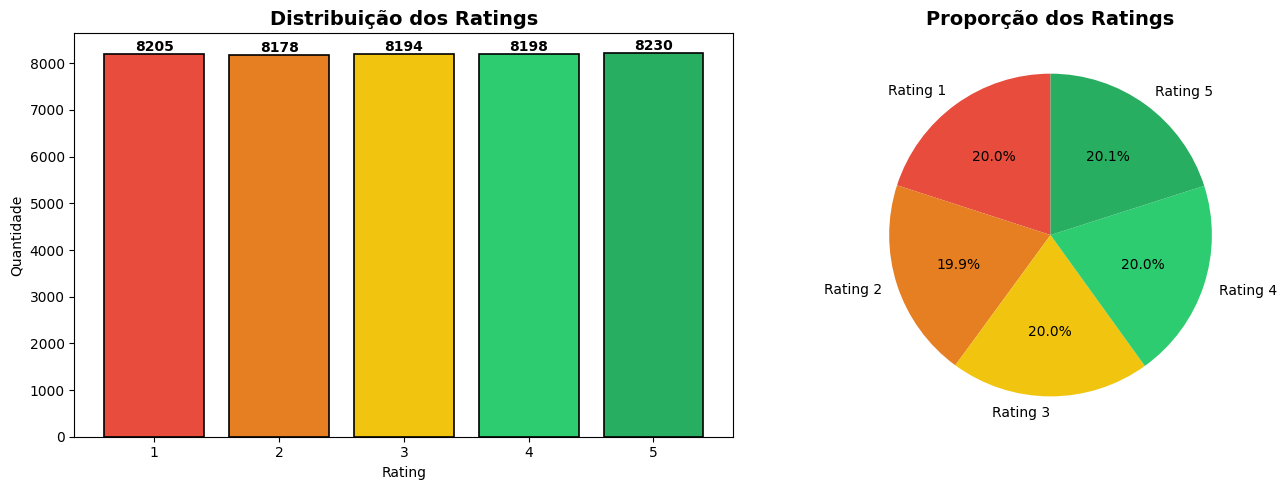


Distribuição:
rating
1    8205
2    8178
3    8194
4    8198
5    8230
Name: count, dtype: int64

Dataset balanceado: 0.2% de variação (ideal = 0%)


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
counts = train['rating'].value_counts().sort_index()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Distribuição dos Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Quantidade')
for bar, val in zip(bars, counts.values):
    axes[0].annotate(f'{val}', xy=(bar.get_x() + bar.get_width()/2, val),
                     ha='center', va='bottom', fontweight='bold')

# Proporção
axes[1].pie(counts.values, labels=[f'Rating {i}' for i in counts.index],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporção dos Ratings', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDistribuição:')
print(counts)
print(f'\nDataset balanceado: {counts.std()/counts.mean()*100:.1f}% de variação (ideal = 0%)')

## 3. Instâncias de Cada Rating

In [31]:
print('=' * 80)
print('EXEMPLOS DE AVALIAÇÕES POR RATING')
print('=' * 80)

for rating in sorted(train['rating'].unique()):
    sample = train[train['rating'] == rating].iloc[0]
    print(f'\n⭐ RATING {rating}')
    print(f'  Título : {sample["title"]}')
    print(f'  Texto  : {sample["text"][:250]}...' if len(sample['text']) > 250 else f'  Texto: {sample["text"]}')
    print('-' * 80)

EXEMPLOS DE AVALIAÇÕES POR RATING

⭐ RATING 1
  Título : Absurdo
  Texto: O readset pode até ser bom, mais tem outros fones no mesmo nível que custam mais baratos, na faixa de R$ 600 a R$ 700 reais, uma pena que veio para o Brasil com esse abuso de preço. Um absurdo isso!
--------------------------------------------------------------------------------

⭐ RATING 2
  Título : Decepção
  Texto  : Foi difícil terminar esse livro , demorou meses ,  cansativo e nada prático,  78% desse livro comentários ou citação de outros livros e mestres. ( nada prático) o restante do próprio autor nada realmente fosse útil  . Eu achei casos citado pelo autor...
--------------------------------------------------------------------------------

⭐ RATING 3
  Título : Ruim
  Texto: Bermuda ruim d++++ eu não recomendo
--------------------------------------------------------------------------------

⭐ RATING 4
  Título : Tamanho pequeno
  Texto: GG diz servir até tamanho 50, porém uso 46 e ficou um tanto aperta

## 4. Léxicos de Sentimento em Português

Listas expandidas baseadas na análise exploratória do corpus.

In [32]:
# ─────────────────────────────────────────────
#  Palavras positivas (PT-BR)
# ─────────────────────────────────────────────
POSITIVE_WORDS = set([
    # qualidade
    'bom','boa','bons','boas','ótimo','ótima','ótimos','ótimas',
    'excelente','excelentes','incrível','incríveis','maravilhoso','maravilhosa',
    'maravilhosos','maravilhosas','fantástico','fantástica','fantásticos',
    'fantásticas','perfeito','perfeita','perfeitos','perfeitas','espetacular',
    'espetaculares','sensacional','sensacionais','top','premium','qualidade',
    # emoção
    'gostei','gostar','adoro','adorei','adoramos','amei','amar','amo',
    'satisfeito','satisfeita','satisfeitos','feliz','felizes','alegre',
    'contente','encantado','encantada','impressionado','impressionada',
    'surpreendido','surpreendida','surpreso','surpresa',
    # recomendação
    'recomendo','recomendado','recomendada','recomendável','indico','vale',
    'compensa','ótima compra','valeu','valendo',
    # utilidade
    'funciona','funcionou','funcionando','funcional','prático','prática',
    'eficiente','eficientes','eficaz','eficazes','útil','úteis','rápido',
    'rápida','rápidos','fácil','fáceis','simples','resistente',
    # aparência
    'bonito','bonita','bonitos','bonitas','lindo','linda','lindos','lindas',
    'elegante','elegantes','moderno','moderna','design',
    # outros
    'agradável','agradáveis','confortável','confortáveis','original',
    'genuíno','autêntico','durável','resistente','robusto','robusto',
    'melhor','melhores','brilhante','amável','confiável','bem','super',
    'muito bom','muito boa','muito bem','bastante'
])

# ─────────────────────────────────────────────
#  Palavras negativas (PT-BR)
# ─────────────────────────────────────────────
NEGATIVE_WORDS = set([
    # qualidade
    'ruim','ruins','péssimo','péssima','péssimos','péssimas',
    'horrível','horríveis','terrível','terríveis','horroroso','horrorosa',
    'deplorável','lamentável','miserável','ridículo','ridícula','absurdo','absurda',
    'lixo','lixeira','inútil','inúteis','imprestável','imprestáveis','fraco','fraca',
    # emoção
    'odiei','odiar','odeio','detestei','detestar','detesto','decepcionado',
    'decepcionada','decepcionante','decepcionou','decepciona','frustrado',
    'frustrada','frustrante','insatisfeito','insatisfeita','triste','raiva',
    'irritante','irritado','irritada','aborrecido','chateado','chateada',
    # problema
    'problema','problemas','defeito','defeitos','falha','falhas','erro','erros',
    'bug','bugs','quebrado','quebrada','danificado','danificada','estragado',
    'estragada','travou','travando','lento','lenta','lentos','lentas',
    # desonestidade
    'enganoso','enganosa','enganado','enganada','fraude','fraudulento','falso',
    'falsa','propaganda','mentira','mentiroso','desperdício','arrependido',
    # custo
    'caro','cara','caros','caras','abusivo','abusiva','injusto','injusta',
    # intensificadores negativos
    'pior','piores','jamais','nunca mais','horrendo','horrenda','insuportável',
    'insuportáveis','desagradável','desagradáveis','demorado','demorada',
    'demora','atraso','atrasado'
])

# ─────────────────────────────────────────────
#  Negações
# ─────────────────────────────────────────────
NEGATION_WORDS = {'não','nao','nunca','nem','jamais','nenhum','nenhuma','nada'}

# ─────────────────────────────────────────────
#  Palavras positivas no título (alta correlação)
# ─────────────────────────────────────────────
POS_TITLE_WORDS = [
    'ótimo','excelente','perfeito','maravilhoso','adorei','incrível',
    'amei','recomendo','top','bom','boa','amei','lindo','linda',
    'funciona','vale','satisfeito'
]
NEG_TITLE_WORDS = [
    'péssimo','péssima','ruim','horrível','terrível','decepção','absurdo',
    'lixo','problema','defeito','fraude','enganoso','odiei','detestei',
    'frustrado','horrendo','inútil'
]

print(f'✅ Léxico positivo: {len(POSITIVE_WORDS)} palavras')
print(f'✅ Léxico negativo: {len(NEGATIVE_WORDS)} palavras')

✅ Léxico positivo: 116 palavras
✅ Léxico negativo: 109 palavras


In [33]:
# ─────────────────────────────────────────────
#  SentiLex (se disponível) + VADER
# ─────────────────────────────────────────────
sia = SentimentIntensityAnalyzer()

SENTILEX = {}
try:
    with open('data/sentilex.txt', encoding='utf-8') as f:
        for line in f:
            parts = line.split(';')
            word = parts[0].split(',')[0].split('.')[0]
            polarity = 0
            for p in parts:
                if 'POL:N0=' in p:
                    try:
                        polarity = int(p.split('=')[1])
                    except:
                        pass
            if word not in SENTILEX or abs(polarity) > abs(SENTILEX[word]):
                SENTILEX[word] = polarity
    print(f'✅ SentiLex carregado: {len(SENTILEX)} entradas')
except FileNotFoundError:
    print('⚠️  SentiLex não encontrado — features de sentilex serão zero.')

✅ SentiLex carregado: 7010 entradas


## 5. Extração de Features

### Visão Geral das Features (base + tom ambíguo)

| # | Feature | Grupo | Justificativa |
|---|---------|-------|---------------|
| 1 | `text_length` | Estrutural | Textos negativos são mais longos (media: 127 chars) vs positivos (81 chars) |
| 2 | `word_count` | Estrutural | Correlação com engajamento e tipo de review |
| 3 | `avg_word_length` | Lexical | Vocabulário mais elaborado → textos mais detalhados |
| 4 | `title_length` | Estrutural | Títulos negativos são ligeiramente mais longos |
| 5 | `sentence_count` | Estrutural | Mais sentenças → mais argumentos (frequentemente negativos) |
| 6 | `avg_words_per_sentence` | Estrutural | Frases longas indicam explicações detalhadas |
| 7 | `exclamation_count` | Pontuação | Bimodal: alta em rating 1 e 5 |
| 8 | `question_count` | Pontuação | Questões são mais comuns em reviews negativos |
| 9 | `positive_word_count` | Sentimento | Contagem direta de palavras positivas em PT-BR |
| 10 | `negative_word_count` | Sentimento | Contagem direta de palavras negativas em PT-BR |
| 11 | `sentiment_score` | Sentimento | pos - neg (sinal claro de polaridade) |
| 12 | `sentiment_ratio` | Sentimento | pos / (pos + neg) normalizado |
| 13 | `negation_count` | Sentimento | 'não' muito mais frequente em ratings 1-2 |
| 14 | `negated_positive_count` | Sentimento | 'não funciona', 'não gostei' — padrão de frustração |
| 15 | `title_sentiment` | Sentimento-Título | Títulos com palavras neg/pos têm forte correlação |
| 16 | `sentilex_score` | Sentimento-Lexical | Score do SentiLex (léxico PT especializado) |
| 17 | `sentilex_positive` | Sentimento-Lexical | Contagem de palavras positivas no SentiLex |
| 18 | `sentilex_negative` | Sentimento-Lexical | Contagem de palavras negativas no SentiLex |
| 19 | `vader_compound` | Sentimento-VADER | Score VADER composto (mesmo em inglês captura padrões) |
| 20 | `capital_ratio` | Intensidade | CAPS = ênfase emocional (raiva ou entusiasmo) |
| 21 | `uppercase_word_count` | Intensidade | Palavras totalmente em maiúsculo |
| 22 | `elongated_word_count` | Intensidade | 'muiiito' = ênfase emocional |
| 23 | `emoji_count` | Intensidade | Emojis indicam emoção (positiva ou negativa) |
| 24 | `digit_count` | Lexical | Números (preços, datas) mais freq. em textos negativos |
| 25 | `lexical_diversity` | Lexical | Textos mais ricos lexicalmente tendem a ser mais pensados |
| 26 | `ellipsis_count` | Pontuação | Reticências indicam insatisfação ou sarcasmo |
| 27 | `max_word_length` | Lexical | Palavras longas indicam vocabulário técnico/emocional |
| 28 | `emotional_intensity` | Intensidade | Combinação de exclamações + CAPS |
| 29 | `unique_word_count` | Lexical | Vocabulário único |
| 30 | `nao_density` | Sentimento | Frequência relativa de 'não' no texto |
| 31 | `contrast_word_count` | Tom ambíguo | Conjunções adversativas (mas, porém, contudo…) |
| 32 | `contrast_phrase_count` | Tom ambíguo | Frases multi-palavra (só que, apesar de, por outro lado…) |
| 33 | `hedge_word_count` | Tom ambíguo | Atenuação / grau (razoável, meio, talvez…) |
| 34 | `comparative_word_count` | Tom ambíguo | Comparação (melhor, pior, versus, parecido…) |
| 35 | `price_context_count` | Tom ambíguo | Âncoras de preço/custo (preço, reais, faixa…) |
| 36 | `list_marker_line_count` | Tom ambíguo | Linhas tipo lista (+/−/•) — prós e contras |
| 37 | `pros_cons_keyword_count` | Tom ambíguo | Menções a prós/contras no texto |
| 38 | `mixed_polarity_flag` | Tom ambíguo | 1 se há palavras pos e neg no léxico (review mista) |
| 39 | `hedge_ratio` | Tom ambíguo | hedging / nº palavras |
| 40 | `contrast_ratio` | Tom ambíguo | (contraste palavra + frase) / nº palavras |

### 5.1 Funções Individuais (documentadas)

In [34]:
# ─── Padrão de emoji ───
EMOJI_PATTERN = re.compile(
    '[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF'
    '\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF'
    '\U00002702-\U000027B0\U000024C2-\U0001F251]+',
    flags=re.UNICODE
)

# ─── Tokenização (melhor que split): remove pontuação nas bordas, Unicode ───
def tokenize_words(text: str) -> list:
    """Lista de tokens alfanuméricos em minúsculas; 'nao' → 'não' para bater no léxico."""
    if not isinstance(text, str) or not text.strip():
        return []
    t = text.lower()
    raw = re.findall(r'\w+', t, flags=re.UNICODE)
    out = []
    for w in raw:
        if w == 'nao':
            w = 'não'
        out.append(w)
    return out

# ─── Léxicos: tom ambíguo (contraste, grau, comparação, preço) ───
CONTRAST_WORDS = {
    'mas', 'porém', 'porem', 'contudo', 'todavia', 'entretanto', 'senão', 'senao',
    'embora', 'enquanto', 'outrossim',
}
HEDGE_WORDS = {
    'meio', 'pouco', 'relativamente', 'razoável', 'razoavel', 'regular', 'nem',
    'quase', 'mediano', 'medíocre', 'mediocre', 'ok', 'talvez', 'duvidoso',
    'satisfatório', 'satisfatorio', 'aceitável', 'aceitavel', 'assim-assim',
}
COMPARATIVE_WORDS = {
    'melhor', 'pior', 'igual', 'similar', 'parecido', 'parecida', 'comparado',
    'comparada', 'comparar', 'versus', 'superior', 'inferior', 'equivalente',
}
PRICE_CONTEXT_WORDS = {
    'preço', 'preco', 'barato', 'caro', 'caros', 'caras', 'reais', 'real',
    'custo', 'econômico', 'economico', 'faixa', 'valor', 'promoção', 'promocao',
}
# Padrões multi-palavra (texto já em minúsculas)
CONTRAST_PHRASE_PATTERNS = [
    r'(?:só|so)\s+que',
    r'mesmo\s+assim',
    r'apesar\s+de',
    r'por\s+outro\s+lado',
    r'por\s+um\s+lado',
    r'ainda\s+assim',
    r'no\s+entanto',
    r'tanto\s+faz',
]

def contrast_phrase_count(text: str) -> int:
    """Ocorrências de frases adversativas / estrutura argumentativa."""
    if not isinstance(text, str) or not text:
        return 0
    tl = text.lower()
    return sum(len(re.findall(p, tl)) for p in CONTRAST_PHRASE_PATTERNS)

def contrast_word_count_tokens(tokens: list) -> int:
    return sum(1 for w in tokens if w in CONTRAST_WORDS)

def hedge_word_count_tokens(tokens: list) -> int:
    return sum(1 for w in tokens if w in HEDGE_WORDS)

def comparative_word_count_tokens(tokens: list) -> int:
    return sum(1 for w in tokens if w in COMPARATIVE_WORDS)

def price_context_count_tokens(tokens: list) -> int:
    return sum(1 for w in tokens if w in PRICE_CONTEXT_WORDS)

def list_marker_line_count(text: str) -> int:
    """Linhas que parecem lista (+/-/•) — prós e contras explícitos."""
    if not isinstance(text, str) or not text:
        return 0
    n = 0
    for line in text.splitlines():
        s = line.strip()
        if len(s) >= 2 and s[0] in '+-•*·' and s[1] in ' \t':
            n += 1
    return n

def pros_cons_keyword_count(text: str) -> int:
    """Marcadores textuais de seção prós/contras."""
    if not isinstance(text, str):
        return 0
    tl = text.lower()
    return len(re.findall(r'\b(prós|pros|contras)\b', tl))

def mixed_polarity_flag(tokens: list) -> int:
    """1 se há pelo menos uma palavra pos e uma neg no léxico (review ambígua)."""
    pos = sum(w in POSITIVE_WORDS for w in tokens)
    neg = sum(w in NEGATIVE_WORDS for w in tokens)
    return 1 if pos > 0 and neg > 0 else 0

# ─── 1. Comprimento do texto (caracteres) ───
def text_length(text: str) -> int:
    """Número total de caracteres. Reviews negativos tendem a ser mais longos."""
    return len(text) if isinstance(text, str) else 0

# ─── 2. Contagem de palavras ───
def word_count(text: str) -> int:
    """Número de tokens (tokenização Unicode)."""
    return len(tokenize_words(text))

# ─── 3. Comprimento médio das palavras ───
def avg_word_length(text: str) -> float:
    """Média do número de caracteres por palavra."""
    words = tokenize_words(text)
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

# ─── 4. Comprimento do título ───
def title_length(title: str) -> int:
    """Comprimento do título da review. Títulos negativos tendem a ser maiores."""
    return len(title) if isinstance(title, str) else 0

# ─── 5. Número de sentenças ───
def sentence_count(text: str) -> int:
    """Número de sentenças separadas por '.', '!' ou '?'."""
    if not isinstance(text, str):
        return 1
    return max(1, len(re.split(r'[.!?]+', text)) - 1)

# ─── 6. Média de palavras por sentença ───
def avg_words_per_sentence(text: str) -> float:
    """Densidade de palavras por sentença."""
    sents = sentence_count(text)
    return word_count(text) / sents if sents else 0.0

# ─── 7. Contagem de '!' ───
def exclamation_count(text: str) -> int:
    """Exclamações: alta freq. nos extremos (rating 1 e 5)."""
    return text.count('!') if isinstance(text, str) else 0

# ─── 8. Contagem de '?' ───
def question_count(text: str) -> int:
    """Interrogações: mais freq. em reviews negativos (questionamentos)."""
    return text.count('?') if isinstance(text, str) else 0

# ─── 9. Contagem de palavras positivas ───
def positive_word_count(text: str) -> int:
    """Número de palavras do léxico positivo PT-BR."""
    words = tokenize_words(text)
    return sum(w in POSITIVE_WORDS for w in words)

# ─── 10. Contagem de palavras negativas ───
def negative_word_count(text: str) -> int:
    """Número de palavras do léxico negativo PT-BR."""
    words = tokenize_words(text)
    return sum(w in NEGATIVE_WORDS for w in words)

# ─── 11. Score de sentimento ───
def sentiment_score(text: str) -> int:
    """pos - neg: sinal direto da polaridade."""
    return positive_word_count(text) - negative_word_count(text)

# ─── 12. Ratio de sentimento ───
def sentiment_ratio(text: str) -> float:
    """pos / (pos + neg): proporção normalizada."""
    pos = positive_word_count(text)
    neg = negative_word_count(text)
    return pos / (pos + neg) if (pos + neg) > 0 else 0.5

# ─── 13. Contagem de negações ───
def negation_count(text: str) -> int:
    """Freq. de 'não','nem','nunca',etc. Muito mais alto em ratings 1-2."""
    words = tokenize_words(text)
    return sum(w in NEGATION_WORDS for w in words)

# ─── 14. Positivos negados ───
def negated_positive_count(text: str) -> int:
    """'não funciona', 'não recomendo' — sinal forte de insatisfação."""
    words = tokenize_words(text)
    count = 0
    for i, w in enumerate(words[:-1]):
        if w in NEGATION_WORDS and words[i + 1] in POSITIVE_WORDS:
            count += 1
    return count

# ─── 15. Sentimento do título ───
def title_sentiment(title: str) -> int:
    """Score pos-neg no título. Alta correlação: 'Péssimo'=1.27, 'Ótimo'=4.39 avg."""
    t = title.lower() if isinstance(title, str) else ''
    pos = sum(w in t for w in POS_TITLE_WORDS)
    neg = sum(w in t for w in NEG_TITLE_WORDS)
    return pos - neg

# ─── 16. SentiLex Score ───
def sentilex_score(text: str) -> int:
    """Soma das polaridades no léxico SentiLex PT."""
    words = tokenize_words(text)
    return sum(SENTILEX.get(w, 0) for w in words)

# ─── 17. SentiLex positivo ───
def sentilex_positive(text: str) -> int:
    """Contagem de palavras com polaridade positiva no SentiLex."""
    words = tokenize_words(text)
    return sum(1 for w in words if SENTILEX.get(w, 0) > 0)

# ─── 18. SentiLex negativo ───
def sentilex_negative(text: str) -> int:
    """Contagem de palavras com polaridade negativa no SentiLex."""
    words = tokenize_words(text)
    return sum(1 for w in words if SENTILEX.get(w, 0) < 0)

# ─── 19. VADER compound ───
def vader_compound(text: str) -> float:
    """Score composto do VADER (-1 a +1). Captura padrões mesmo em PT."""
    if not isinstance(text, str):
        return 0.0
    return sia.polarity_scores(text)['compound']

# ─── 20. Capital ratio ───
def capital_ratio(text: str) -> float:
    """Proporção de letras maiúsculas. CAPS = ênfase emocional."""
    if not isinstance(text, str):
        return 0.0
    letters = [c for c in text if c.isalpha()]
    return sum(c.isupper() for c in letters) / len(letters) if letters else 0.0

# ─── 21. Palavras totalmente em maiúsculo ───
def uppercase_word_count(text: str) -> int:
    """Contagem de palavras CAPS. Rating 1 tem 0.42 vs 0.09 no rating 5."""
    if not isinstance(text, str):
        return 0
    return sum(1 for w in text.split() if w.isupper() and len(w) > 1)

# ─── 22. Palavras alongadas ───
def elongated_word_count(text: str) -> int:
    """Ex: 'muiiiito', 'pésssimooo' — ênfase emocional."""
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'(.)\1{2,}', text.lower()))

# ─── 23. Emojis ───
def emoji_count(text: str) -> int:
    """Contagem de emojis no texto."""
    return len(EMOJI_PATTERN.findall(text)) if isinstance(text, str) else 0

# ─── 24. Contagem de dígitos ───
def digit_count(text: str) -> int:
    """Dígitos (preços, quantidades). Mais freq. em reviews negativos."""
    if not isinstance(text, str):
        return 0
    return sum(c.isdigit() for c in text)

# ─── 25. Diversidade lexical ───
def lexical_diversity(text: str) -> float:
    """Palavras únicas / total. Texto rico = review mais elaborado."""
    words = tokenize_words(text)
    return len(set(words)) / len(words) if words else 0.0

# ─── 26. Reticências ───
def ellipsis_count(text: str) -> int:
    """Contagem de '...'. Frequente em insatisfação e sarcasmo."""
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'\.{3,}', text))

# ─── 27. Maior palavra ───
def max_word_length(text: str) -> int:
    """Comprimento da maior palavra (vocabulário técnico ou emocional)."""
    words = tokenize_words(text)
    return max(len(w) for w in words) if words else 0

# ─── 28. Intensidade emocional ───
def emotional_intensity(text: str) -> int:
    """Exclamações + palavras CAPS: combina dois sinais de ênfase."""
    return exclamation_count(text) + uppercase_word_count(text)

# ─── 29. Palavras únicas ───
def unique_word_count(text: str) -> int:
    """Número de palavras distintas."""
    return len(set(tokenize_words(text)))

# ─── 30. Densidade de negação ───
def nao_density(text: str) -> float:
    """Freq. relativa de 'não'. Rating 1=0.77, Rating 5=0.14 por review."""
    words = tokenize_words(text)
    if not words:
        return 0.0
    return words.count('não') / len(words)

# ─── 31–40. Tom ambíguo / contraste / hedging ───
def ambiguity_features(text: str) -> tuple:
    """Retorna tupla de features derivadas da mesma tokenização."""
    tokens = tokenize_words(text)
    n = max(1, len(tokens))
    cw = contrast_word_count_tokens(tokens)
    cp = contrast_phrase_count(text)
    hw = hedge_word_count_tokens(tokens)
    comp = comparative_word_count_tokens(tokens)
    prc = price_context_count_tokens(tokens)
    lmc = list_marker_line_count(text)
    pcc = pros_cons_keyword_count(text)
    mpf = mixed_polarity_flag(tokens)
    hedge_r = hw / n
    contrast_r = (cw + cp) / n
    return (cw, cp, hw, comp, prc, lmc, pcc, mpf, hedge_r, contrast_r)

print('✅ Funções de features definidas (30 base + 10 tom ambíguo)!')


✅ Todas as 30 funções de features definidas!


### 5.2 Função Unificada de Extração

In [35]:
FEATURE_NAMES = [
    'text_length', 'word_count', 'avg_word_length', 'title_length',
    'sentence_count', 'avg_words_per_sentence',
    'exclamation_count', 'question_count',
    'positive_word_count', 'negative_word_count', 'sentiment_score', 'sentiment_ratio',
    'negation_count', 'negated_positive_count', 'title_sentiment',
    'sentilex_score', 'sentilex_positive', 'sentilex_negative', 'vader_compound',
    'capital_ratio', 'uppercase_word_count', 'elongated_word_count', 'emoji_count',
    'digit_count', 'lexical_diversity', 'ellipsis_count',
    'max_word_length', 'emotional_intensity', 'unique_word_count', 'nao_density',
    'contrast_word_count', 'contrast_phrase_count', 'hedge_word_count',
    'comparative_word_count', 'price_context_count', 'list_marker_line_count',
    'pros_cons_keyword_count', 'mixed_polarity_flag', 'hedge_ratio', 'contrast_ratio',
]

def extract_all_features(text: str, title: str = '') -> list:
    '''
    Extrai todas as 40 features de um par (text, title).
    Retorna uma lista de floats na ordem de FEATURE_NAMES.
    '''
    if not isinstance(text, str):
        text = ''
    if not isinstance(title, str):
        title = ''

    cw, cp, hw, comp, prc, lmc, pcc, mpf, hedge_r, contrast_r = ambiguity_features(text)

    return [
        text_length(text),
        word_count(text),
        avg_word_length(text),
        title_length(title),
        sentence_count(text),
        avg_words_per_sentence(text),
        exclamation_count(text),
        question_count(text),
        positive_word_count(text),
        negative_word_count(text),
        sentiment_score(text),
        sentiment_ratio(text),
        negation_count(text),
        negated_positive_count(text),
        title_sentiment(title),
        sentilex_score(text),
        sentilex_positive(text),
        sentilex_negative(text),
        vader_compound(text),
        capital_ratio(text),
        uppercase_word_count(text),
        elongated_word_count(text),
        emoji_count(text),
        digit_count(text),
        lexical_diversity(text),
        ellipsis_count(text),
        max_word_length(text),
        emotional_intensity(text),
        unique_word_count(text),
        nao_density(text),
        cw, cp, hw, comp, prc, lmc, pcc, mpf, hedge_r, contrast_r,
    ]

# Teste rápido
test_text = 'Produto péssimo! Não funciona de jeito nenhum. HORRÍVEL!!'
test_feats = extract_all_features(test_text, 'Lixo total')
for name, val in zip(FEATURE_NAMES, test_feats):
    print(f'  {name:30s} = {val}')


  text_length                    = 57
  word_count                     = 8
  avg_word_length                = 6.25
  title_length                   = 10
  sentence_count                 = 3
  avg_words_per_sentence         = 2.6666666666666665
  exclamation_count              = 3
  question_count                 = 0
  positive_word_count            = 1
  negative_word_count            = 0
  sentiment_score                = 1
  sentiment_ratio                = 1.0
  negation_count                 = 1
  negated_positive_count         = 1
  title_sentiment                = -1
  sentilex_score                 = 0
  sentilex_positive              = 0
  sentilex_negative              = 0
  vader_compound                 = 0.0
  capital_ratio                  = 0.21739130434782608
  uppercase_word_count           = 1
  elongated_word_count           = 0
  emoji_count                    = 0
  digit_count                    = 0
  lexical_diversity              = 1.0
  ellipsis_count            

## 6. Preparação dos Dados

In [36]:
print('Extraindo features do conjunto de TREINO...')
X_train_raw = np.array([
    extract_all_features(row['text'], row['title'])
    for _, row in train.iterrows()
])
y_train = train['rating'].values

print('Extraindo features do conjunto de TESTE...')
X_test_raw = np.array([
    extract_all_features(row['text'], row['title'])
    for _, row in test.iterrows()
])

df_features = pd.DataFrame(X_train_raw, columns=FEATURE_NAMES)
df_features['rating'] = y_train

print(f'\n✅ Features extraídas!')
print(f'   X_train: {X_train_raw.shape}   X_test: {X_test_raw.shape}')

Extraindo features do conjunto de TREINO...
Extraindo features do conjunto de TESTE...

✅ Features extraídas!
   X_train: (41005, 30)   X_test: (10252, 30)


## 7. Visualização dos Dados Vetorizados

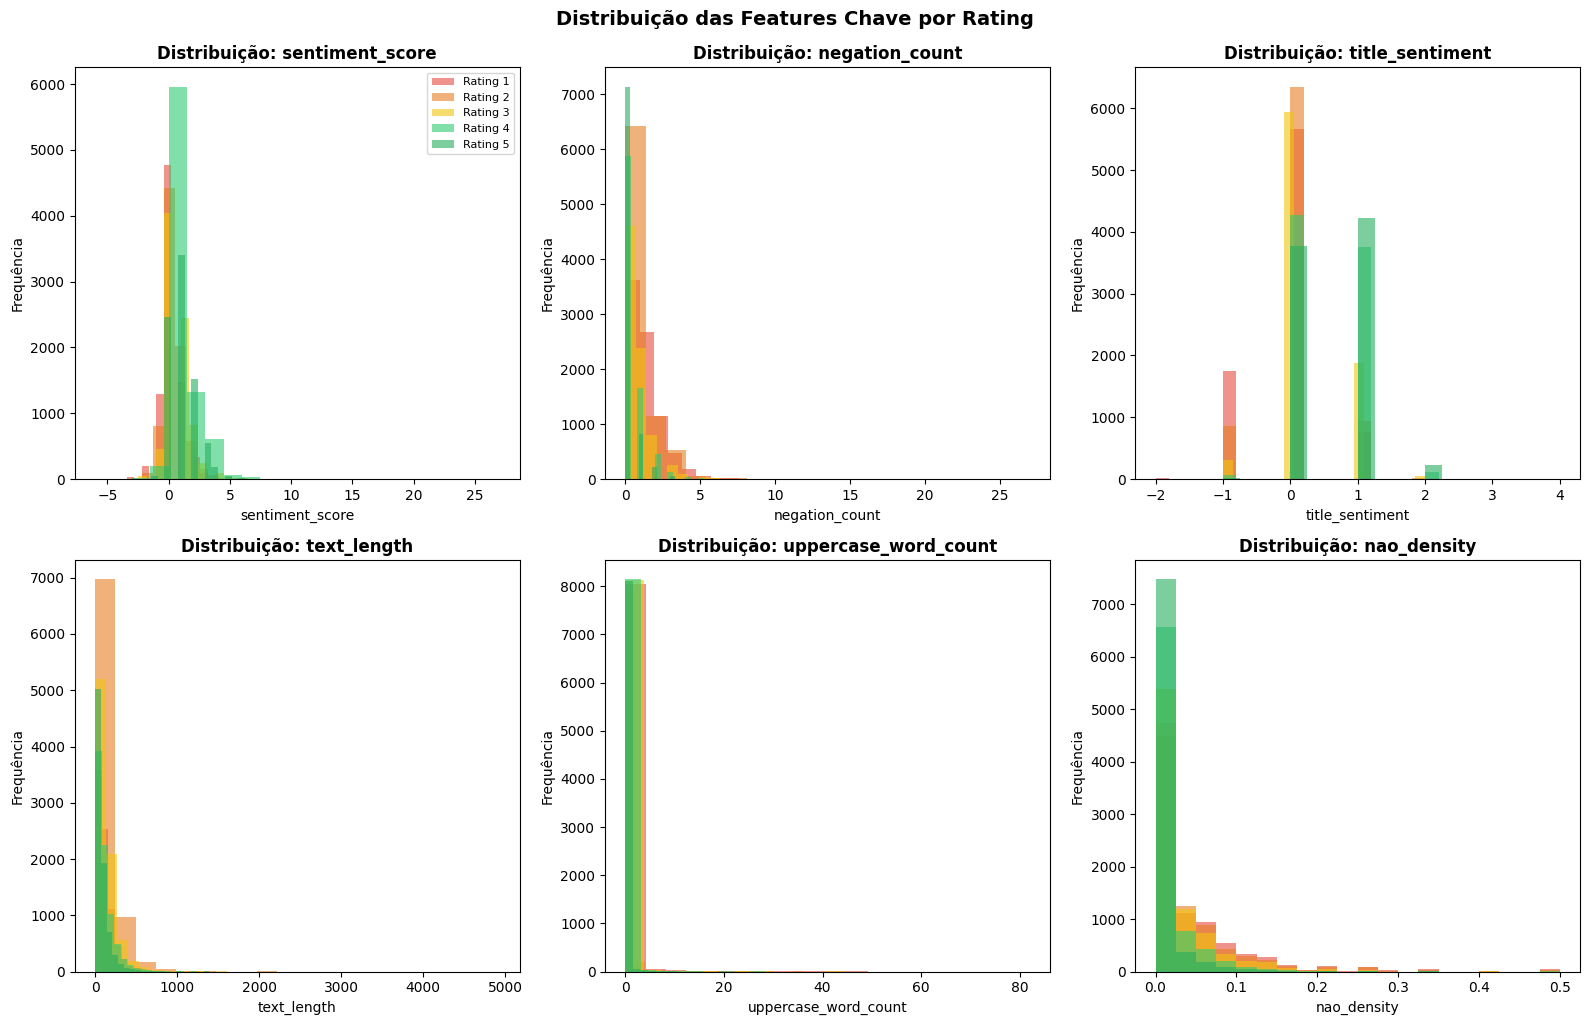

In [37]:
# ─── Distribuição de features por rating ───
key_features = [
    'sentiment_score', 'negation_count', 'title_sentiment',
    'text_length', 'contrast_ratio', 'mixed_polarity_flag'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

for idx, feat in enumerate(key_features):
    for r, c in zip([1,2,3,4,5], colors):
        vals = df_features[df_features['rating'] == r][feat]
        axes[idx].hist(vals, bins=20, alpha=0.6, color=c, label=f'Rating {r}')
    axes[idx].set_title(f'Distribuição: {feat}', fontweight='bold')
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Frequência')
    if idx == 0:
        axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Distribuição das Features Chave por Rating', y=1.02, fontsize=14, fontweight='bold')
plt.show()

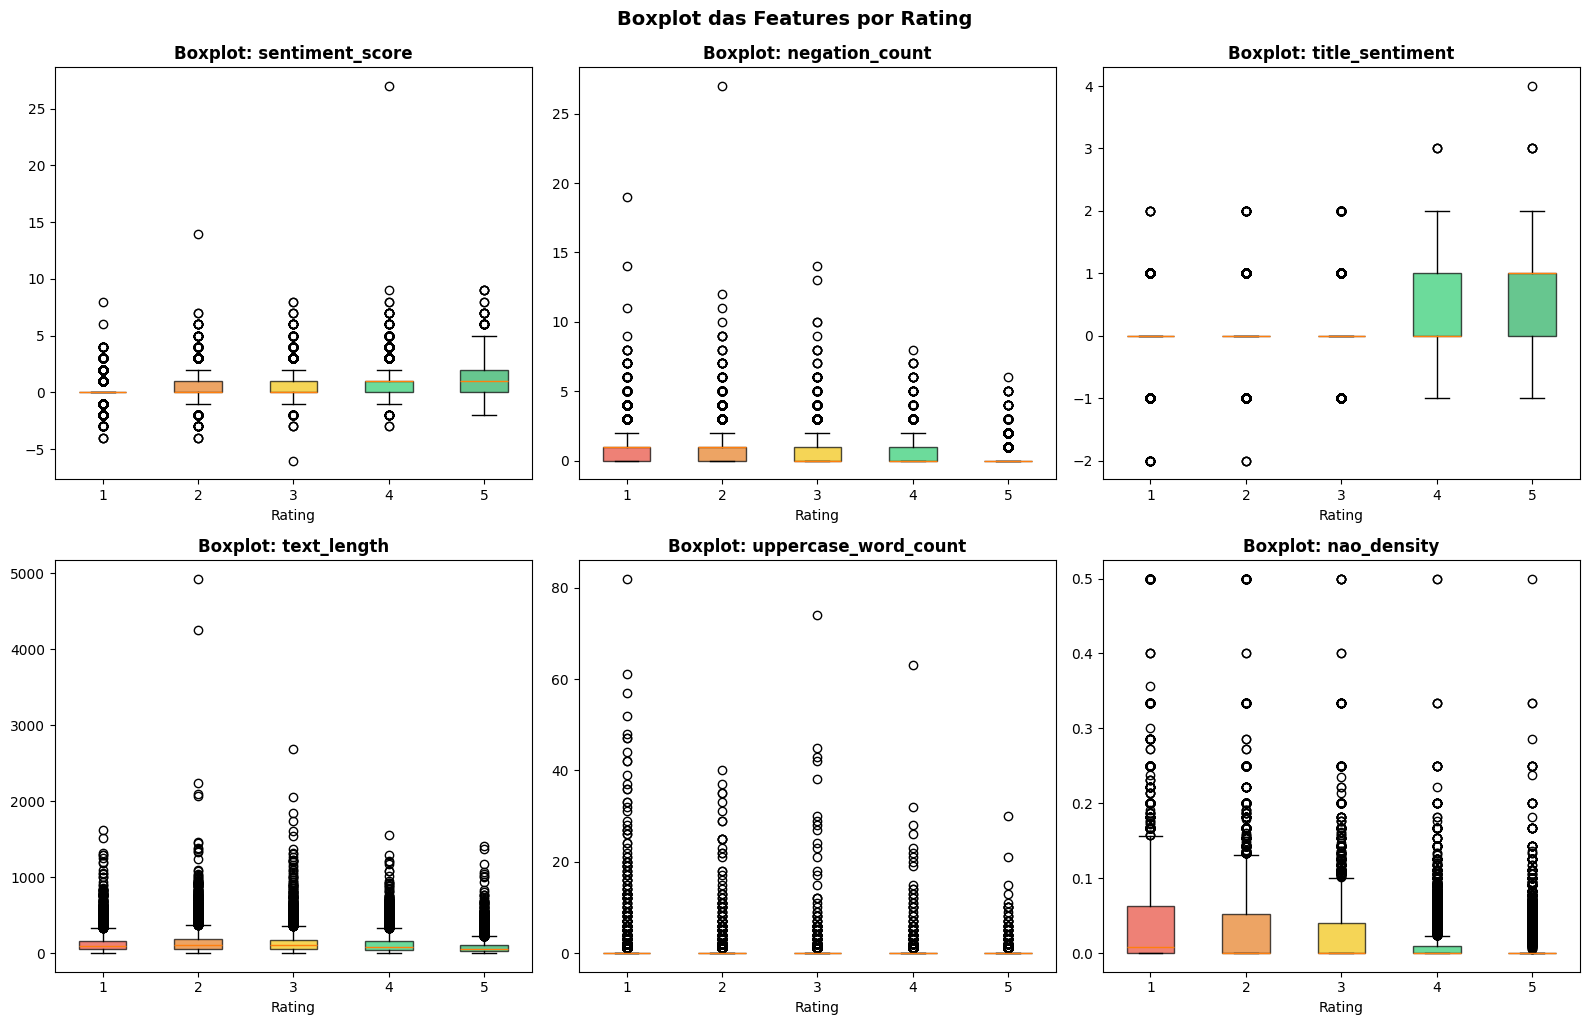

In [38]:
# ─── Média das features por rating (boxplots) ───
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    data_by_rating = [df_features[df_features['rating'] == r][feat].values for r in [1,2,3,4,5]]
    bp = axes[idx].boxplot(data_by_rating, labels=[1,2,3,4,5], patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    axes[idx].set_title(f'Boxplot: {feat}', fontweight='bold')
    axes[idx].set_xlabel('Rating')

plt.tight_layout()
plt.suptitle('Boxplot das Features por Rating', y=1.02, fontsize=14, fontweight='bold')
plt.show()

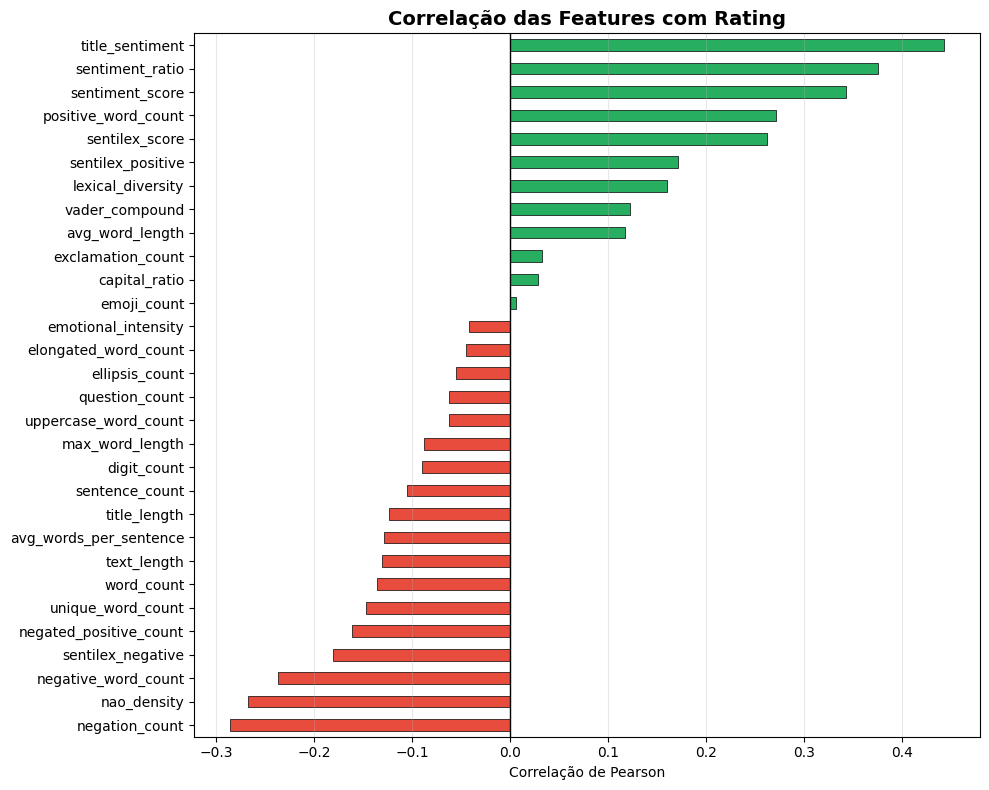


Top 10 features com maior correlação (abs) com rating:
title_sentiment        0.443294
sentiment_ratio        0.375857
sentiment_score        0.342511
negation_count         0.285879
positive_word_count    0.271493
nao_density            0.267016
sentilex_score         0.262671
negative_word_count    0.236963
sentilex_negative      0.180261
sentilex_positive      0.171745
Name: rating, dtype: float64


In [39]:
# ─── Heatmap de correlação (features vs rating) ───
corr_with_rating = df_features.corr()['rating'].drop('rating').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_with_rating]
corr_with_rating.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.set_title('Correlação das Features com Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlação de Pearson')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 10 features com maior correlação (abs) com rating:')
print(corr_with_rating.abs().sort_values(ascending=False).head(10))

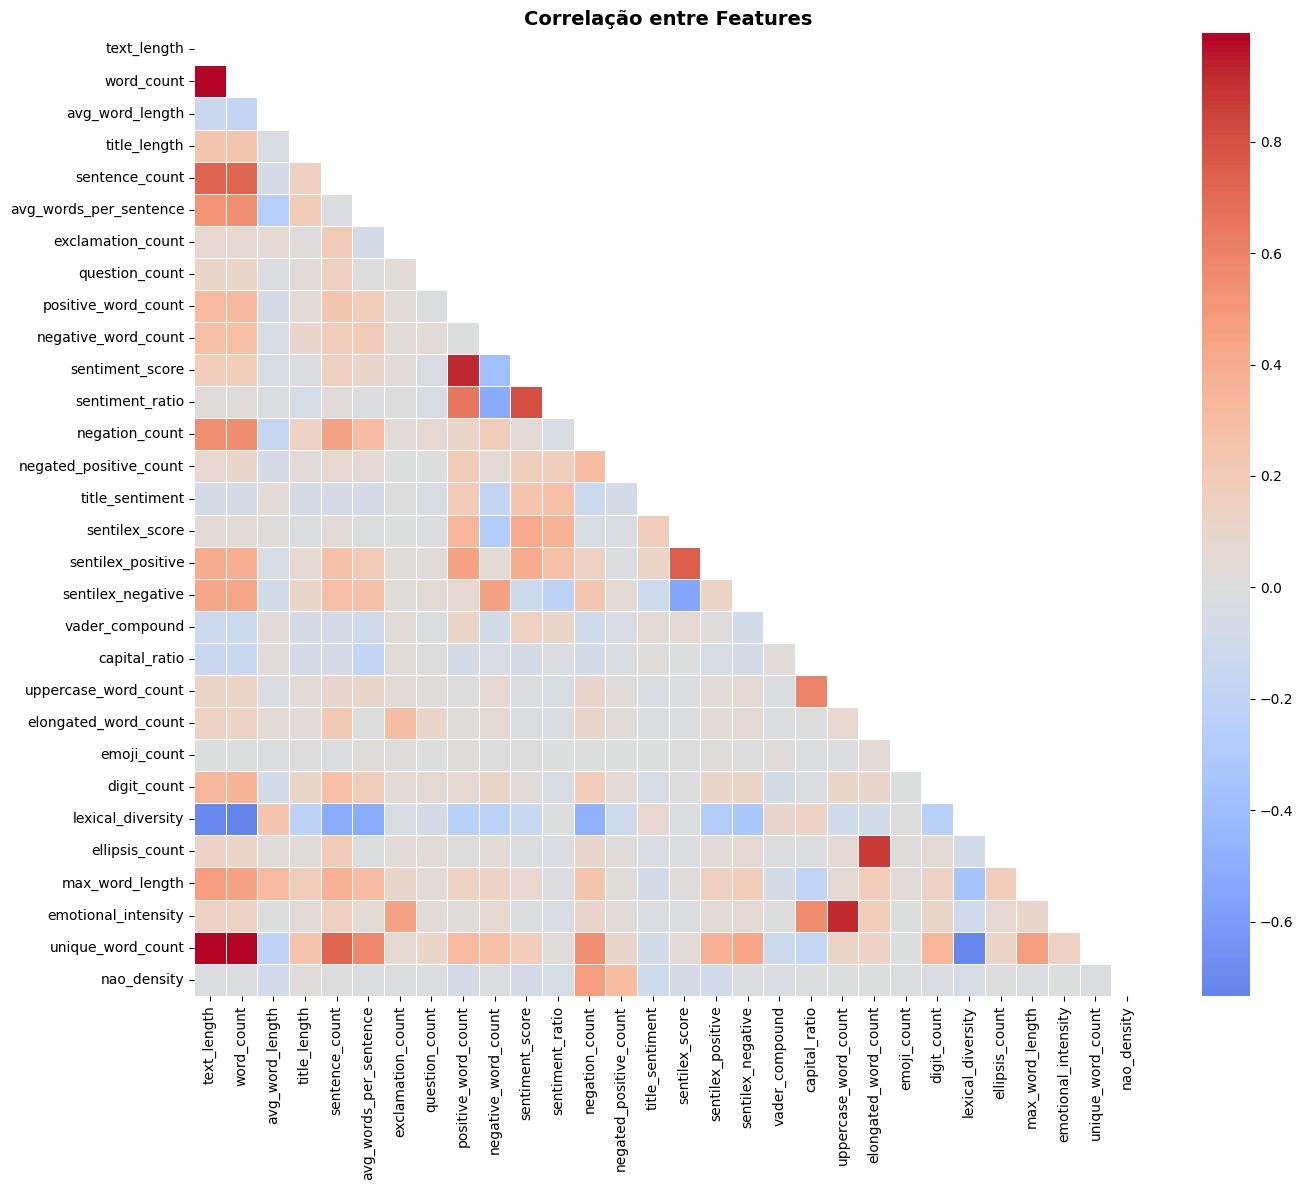

In [40]:
# ─── Heatmap de correlação entre features ───
plt.figure(figsize=(14, 12))
corr_matrix = df_features.drop('rating', axis=1).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, fmt='.1f', linewidths=0.5)
plt.title('Correlação entre Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Describe dos Dados

In [41]:
desc = df_features.drop('rating', axis=1).describe().T
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(3)  # Coef. de variação
desc = desc.round(4)

print('=== Estatísticas Descritivas das Features ===')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(desc[['mean','std','min','25%','50%','75%','max','cv']])

=== Estatísticas Descritivas das Features ===
                            mean       std    min      25%      50%       75%        max      cv
text_length             121.3628  129.4781  0.000  43.0000  85.0000  156.0000  4930.0000   1.067
word_count               21.3057   22.8058  0.000   7.0000  15.0000   28.0000   865.0000   1.070
avg_word_length           4.9674    1.1271  0.000   4.3571   4.7778    5.3333    69.0000   0.227
title_length             20.1560   14.5889  0.000  10.0000  16.0000   26.0000   165.0000   0.724
sentence_count            1.8274    1.3951  1.000   1.0000   1.0000    2.0000    40.0000   0.763
avg_words_per_sentence   11.8388    9.5359  0.000   6.0000  10.0000   15.0000   230.0000   0.805
exclamation_count         0.2313    0.7698  0.000   0.0000   0.0000    0.0000    26.0000   3.328
question_count            0.0192    0.1972  0.000   0.0000   0.0000    0.0000     7.0000  10.289
positive_word_count       0.7804    1.0109  0.000   0.0000   1.0000    1.0000    

In [42]:
# ─── Média por rating ───
print('=== Média das features por Rating ===')
print(df_features.groupby('rating')[FEATURE_NAMES].mean().round(3).T)

=== Média das features por Rating ===
rating                        1        2        3        4       5
text_length             127.579  145.100  135.268  117.743  81.339
word_count               22.329   25.603   24.081   20.718  13.839
avg_word_length           4.946    4.834    4.764    4.922   5.368
title_length             21.632   21.807   21.515   19.320  16.523
sentence_count            1.958    2.011    1.845    1.754   1.570
avg_words_per_sentence   12.134   13.300   13.424   11.806   8.546
exclamation_count         0.305    0.159    0.129    0.177   0.386
question_count            0.040    0.025    0.016    0.009   0.005
positive_word_count       0.400    0.586    0.730    1.044   1.140
negative_word_count       0.309    0.221    0.138    0.074   0.024
sentiment_score           0.090    0.365    0.592    0.970   1.116
sentiment_ratio           0.523    0.613    0.686    0.790   0.842
negation_count            0.950    0.885    0.669    0.402   0.181
negated_positive_count  

## 9. Normalização das Features

In [43]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

print(f'X_train normalizado: shape={X_train_scaled.shape}')
print(f'X_test  normalizado: shape={X_test_scaled.shape}')
print(f'Média pós-normalização (deve ser ~0): {X_train_scaled.mean(axis=0)[:5].round(6)}')
print(f'Std pós-normalização  (deve ser ~1): {X_train_scaled.std(axis=0)[:5].round(6)}')

X_train normalizado: shape=(41005, 30)
X_test  normalizado: shape=(10252, 30)
Média pós-normalização (deve ser ~0): [-0. -0.  0.  0.  0.]
Std pós-normalização  (deve ser ~1): [1. 1. 1. 1. 1.]


## 10. Treinamento — SVM com Validação Cruzada

In [44]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.1,
    class_weight='balanced',
    random_state=SEED
)

print('Rodando validação cruzada (5-fold) — SVM RBF...')
svm_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

print(f'\n📊 SVM — Acurácia por fold: {[round(s,4) for s in svm_scores]}')
print(f'📊 SVM — Média: {svm_scores.mean():.4f}  |  Std: {svm_scores.std():.4f}')

Rodando validação cruzada (5-fold) — SVM RBF...

📊 SVM — Acurácia por fold: [np.float64(0.3706), np.float64(0.37), np.float64(0.3743), np.float64(0.375), np.float64(0.36)]
📊 SVM — Média: 0.3700  |  Std: 0.0054


In [ ]:
# ─── Comparação com outros modelos clássicos ───
models = {
    'SVM (Linear)': SVC(kernel='linear', C=1, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1),
    'Logistic Regression': LogisticRegression(C=1, max_iter=500, random_state=SEED, n_jobs=-1),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:35s} | Folds: {[round(s,4) for s in scores]} | Média: {scores.mean():.4f}')

print('\n🏆 Melhor modelo:', max(results, key=lambda k: results[k].mean()))

SVM (RBF, C=10)                     | Folds: [np.float64(0.3706), np.float64(0.37), np.float64(0.3743), np.float64(0.375), np.float64(0.36)] | Média: 0.3700
SVM (Linear)                        | Folds: [np.float64(0.3951), np.float64(0.3925), np.float64(0.409), np.float64(0.395), np.float64(0.4015)] | Média: 0.3986
Random Forest                       | Folds: [np.float64(0.3987), np.float64(0.3989), np.float64(0.4028), np.float64(0.4057), np.float64(0.4004)] | Média: 0.4013
Logistic Regression                 | Folds: [np.float64(0.3987), np.float64(0.3995), np.float64(0.4112), np.float64(0.4), np.float64(0.3998)] | Média: 0.4018

🏆 Melhor modelo: Logistic Regression


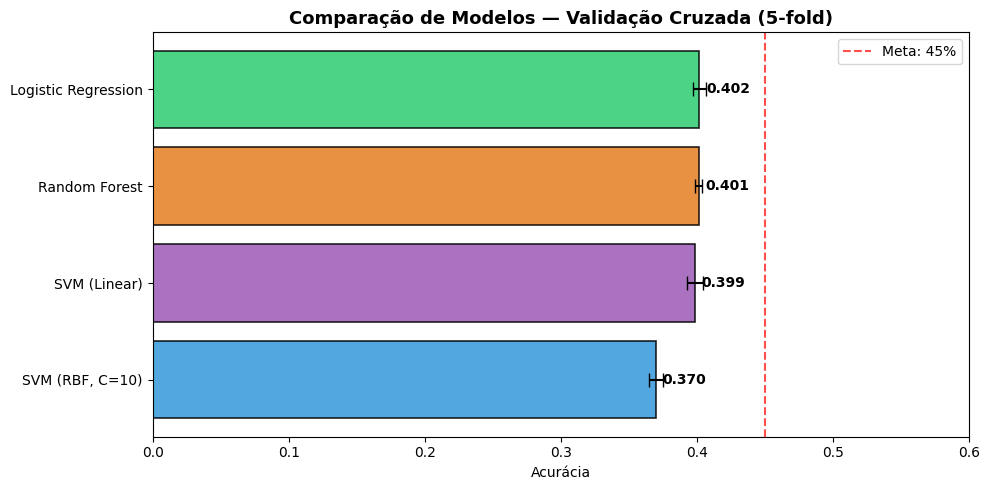

In [46]:
# ─── Visualização dos resultados ───
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results.keys())
means = [results[m].mean() for m in model_names]
stds  = [results[m].std()  for m in model_names]

bars = ax.barh(model_names, means, xerr=stds, color=['#3498db','#9b59b6','#e67e22','#2ecc71'],
               edgecolor='black', linewidth=1.2, capsize=5, alpha=0.85)
ax.set_xlim(0, 0.6)
ax.axvline(x=0.45, color='red', linestyle='--', alpha=0.7, label='Meta: 45%')
ax.set_title('Comparação de Modelos — Validação Cruzada (5-fold)', fontsize=13, fontweight='bold')
ax.set_xlabel('Acurácia')
for bar, val in zip(bars, means):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Média dos Folds

In [47]:
print('=' * 55)
print('RESUMO — MÉDIA DOS FOLDS (5-fold CV, seed=42)')
print('=' * 55)
for name, scores in results.items():
    print(f'{name:35s}: {scores.mean():.4f} ± {scores.std():.4f}')
print('=' * 55)

best_model_name = max(results, key=lambda k: results[k].mean())
print(f'\n🥇 Melhor modelo: {best_model_name} ({results[best_model_name].mean():.4f})')

RESUMO — MÉDIA DOS FOLDS (5-fold CV, seed=42)
SVM (RBF, C=10)                    : 0.3700 ± 0.0054
SVM (Linear)                       : 0.3986 ± 0.0060
Random Forest                      : 0.4013 ± 0.0026
Logistic Regression                : 0.4018 ± 0.0047

🥇 Melhor modelo: Logistic Regression (0.4018)


## 11.1 Avaliação: QWK e matriz de confusão (OOF)

Predições **out-of-fold** com o mesmo `KFold` — cada amostra é predita por um modelo treinado **sem** ela no treino. Isso evita viés otimista (diferente de avaliar no treino após `fit` no conjunto inteiro).

- **QWK** (`cohen_kappa_score`, `weights='quadratic'`): penaliza mais erros grandes na escala 1–5.
- **Matriz de confusão**: classes reais (linhas) × preditas (colunas).

Modelo (OOF): Logistic Regression
Accuracy (OOF): 0.4018
QWK (quadratic): 0.5936

              precision    recall  f1-score   support

           1     0.4446    0.5755    0.5017      8205
           2     0.3261    0.2256    0.2667      8178
           3     0.2988    0.2856    0.2920      8194
           4     0.3535    0.2687    0.3053      8198
           5     0.5033    0.6521    0.5681      8230

    accuracy                         0.4018     41005
   macro avg     0.3853    0.4015    0.3868     41005
weighted avg     0.3854    0.4018    0.3870     41005



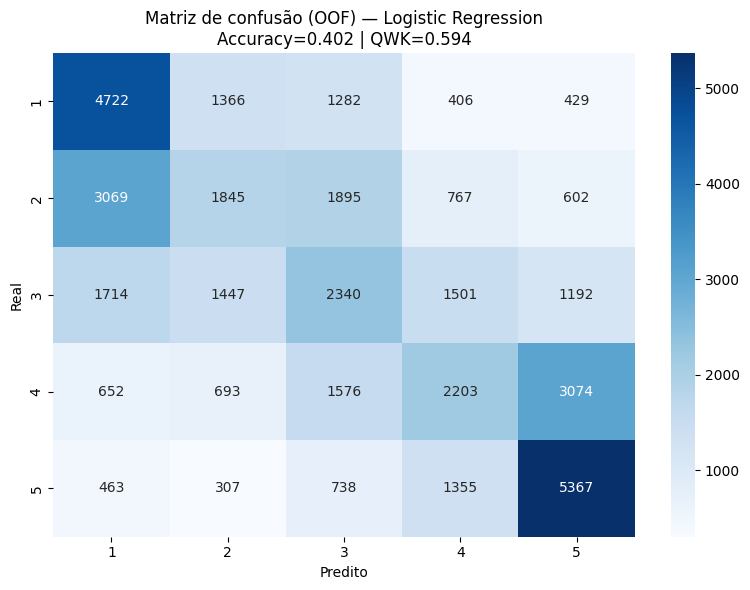

In [48]:
RATING_LABELS = [1, 2, 3, 4, 5]

# Clone do melhor estimador (cross_val_predict também clona internamente; assim não acumulamos estado em `models[...]`)
est_oof = clone(models[best_model_name])
y_oof = cross_val_predict(est_oof, X_train_scaled, y_train, cv=kf, n_jobs=-1)

acc_oof = accuracy_score(y_train, y_oof)
qwk_oof = cohen_kappa_score(y_train, y_oof, labels=RATING_LABELS, weights='quadratic')
cm_oof = confusion_matrix(y_train, y_oof, labels=RATING_LABELS)

print(f'Modelo (OOF): {best_model_name}')
print(f'Accuracy (OOF): {acc_oof:.4f}')
print(f'QWK (quadratic): {qwk_oof:.4f}')
print()
print(classification_report(y_train, y_oof, labels=RATING_LABELS, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_oof,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=RATING_LABELS,
    yticklabels=RATING_LABELS,
    ax=ax,
)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusão (OOF) — {best_model_name}\nAccuracy={acc_oof:.3f} | QWK={qwk_oof:.3f}')
plt.tight_layout()
plt.show()

## 12. Treinamento no Conjunto Completo

In [49]:
# Treinar o melhor modelo no dataset completo
best_model = models[best_model_name]
print(f'Treinando {best_model_name} no dataset completo...')
best_model.fit(X_train_scaled, y_train)
train_acc = best_model.score(X_train_scaled, y_train)
print(f'✅ Treinamento concluído! Acurácia no treino: {train_acc:.4f}')

Treinando Logistic Regression no dataset completo...
✅ Treinamento concluído! Acurácia no treino: 0.4047


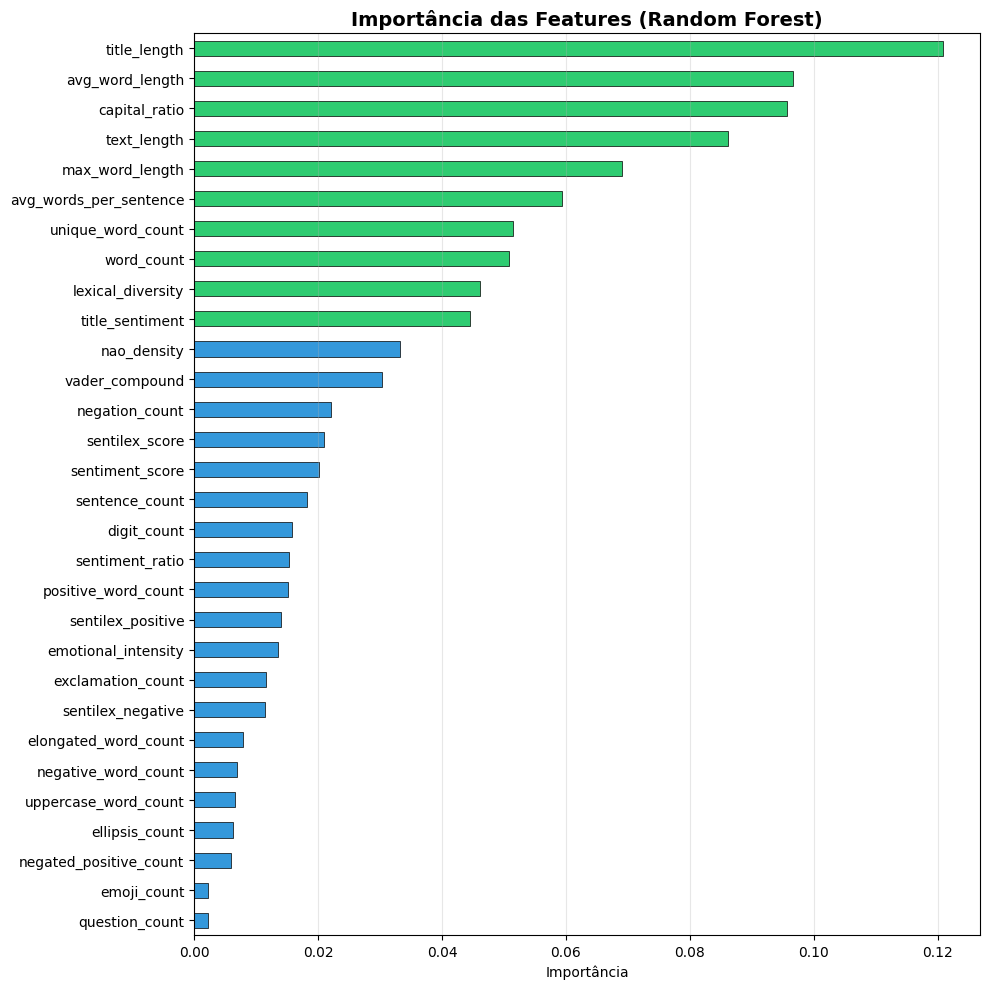


🏆 Top 10 features mais importantes:
title_length              0.120787
avg_word_length           0.096669
capital_ratio             0.095601
text_length               0.086116
max_word_length           0.068971
avg_words_per_sentence    0.059283
unique_word_count         0.051373
word_count                0.050740
lexical_diversity         0.046056
title_sentiment           0.044469
dtype: float64


In [50]:
# ─── Importância de features (via Random Forest) ───
rf_for_importance = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_for_importance.fit(X_train_scaled, y_train)

importances = pd.Series(rf_for_importance.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors_imp = ['#2ecc71' if i >= len(importances) - 10 else '#3498db' for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='black', linewidth=0.5)
ax.set_title('Importância das Features (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n🏆 Top 10 features mais importantes:')
print(importances.sort_values(ascending=False).head(10))

## 13. Predições e Submissão

In [51]:
predictions = best_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'id': test['id'],
    'rating': predictions
})

submission.to_csv('submission.csv', index=False)

print(f'✅ Arquivo submission.csv gerado!')
print(f'   Total de predições: {len(submission)}')
print(f'\nDistribuição das predições:')
print(submission['rating'].value_counts().sort_index())
print(f'\nPrimeiras 10 predições:')
print(submission.head(10))

✅ Arquivo submission.csv gerado!
   Total de predições: 10252

Distribuição das predições:
rating
1    2600
2    1439
3    1989
4    1503
5    2721
Name: count, dtype: int64

Primeiras 10 predições:
      id  rating
0  40261       3
1  46176       1
2  47942       4
3  37329       2
4  13503       5
5  41006       5
6  42233       5
7  21180       1
8  20621       2
9  28630       3


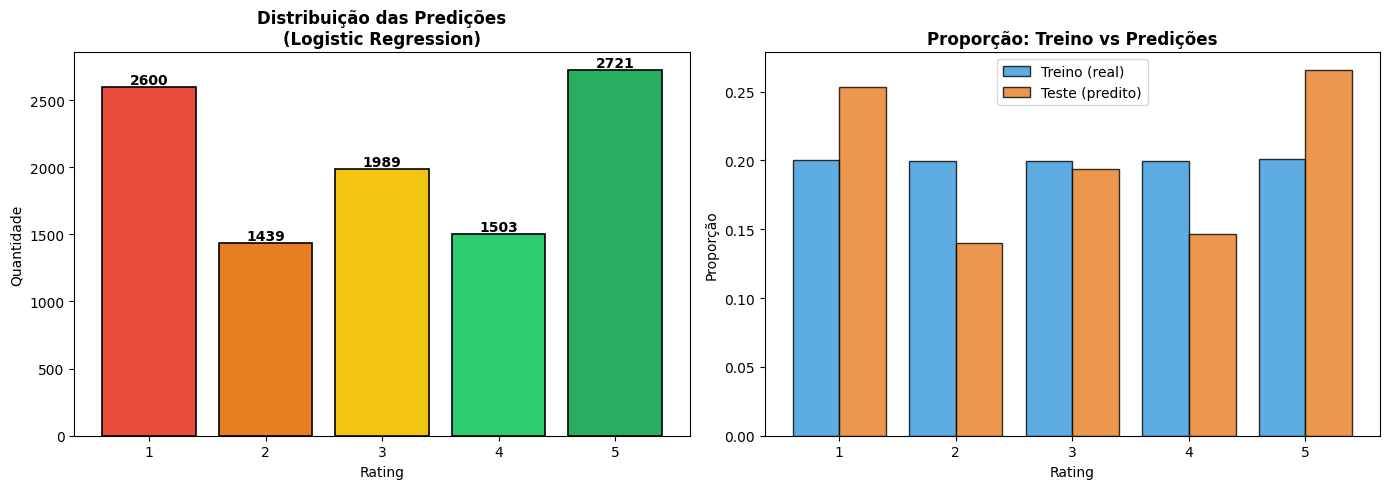

In [52]:
# ─── Visualização das predições ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predições
pred_counts = submission['rating'].value_counts().sort_index()
axes[0].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.2)
for i, (idx, val) in enumerate(pred_counts.items()):
    axes[0].annotate(f'{val}', xy=(idx, val), ha='center', va='bottom', fontweight='bold')
axes[0].set_title(f'Distribuição das Predições\n({best_model_name})', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Quantidade')

# Comparação treino vs predição
train_counts = train['rating'].value_counts().sort_index()
x = np.arange(1, 6)
axes[1].bar(x - 0.2, train_counts.values / train_counts.sum(), 0.4,
            label='Treino (real)', color='#3498db', alpha=0.8, edgecolor='black')
axes[1].bar(x + 0.2, pred_counts.values / pred_counts.sum(), 0.4,
            label='Teste (predito)', color='#e67e22', alpha=0.8, edgecolor='black')
axes[1].set_title('Proporção: Treino vs Predições', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Proporção')
axes[1].legend()
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()